# Brain — Multi-Agent System
**Google Colab notebook** — clone the repo, install deps, mount Drive for persistence, run the brain.

Recommended runtime: **L4 GPU** (Colab Pro) or **T4** (free tier).

If you want local Ollama models instead of Gemini, jump to the **Ollama (optional)** section.

## 1 — Mount Google Drive (data persistence)
ChromaDB and the episode SQLite database will be stored on Drive so they survive session restarts.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, pathlib

# All persistent data goes here — survives session restarts
DRIVE_DATA = '/content/drive/MyDrive/Brain/data'
pathlib.Path(DRIVE_DATA).mkdir(parents=True, exist_ok=True)

# Symlink so the code always finds data/ in the repo root
REPO_DATA = '/content/Brain/data'
if os.path.islink(REPO_DATA):
    os.remove(REPO_DATA)
# (symlink created after clone in step 3)
print(f'Drive mounted. Data will persist at: {DRIVE_DATA}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Data will persist at: /content/drive/MyDrive/Brain/data


## 2 — Clone the repo

In [2]:
import os

REPO_URL = 'https://github.com/Seydifa/Brain.git'
REPO_DIR = '/content/Brain'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}
print('Working directory:', os.getcwd())

remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 16 (delta 13), reused 14 (delta 11), pack-reused 0 (from 0)
Unpacking objects: 100% (16/16), 18.81 KiB | 1.88 MiB/s, done.
From https://github.com/Seydifa/Brain
   773c315..ef602ad  main       -> origin/main
Updating 773c315..ef602ad
Fast-forward
 agents/goal_evaluator.py   |   2 +-
 agents/orchestrator.py     |   2 +-
 agents/qa_agent.py         |   2 +-
 agents/search_agent.py     |  92 ++++-
 agents/search_validator.py |   2 +-
 colab.ipynb                | 956 ++++++++++++++++++++++++++++++---------------
 memory/agent.py            |   2 +-
 memory/store.py            |   2 +-
 prompts.py                 |  29 +-
 9 files changed, 762 insertions(+), 327 deletions(-)
/content/Brain
Working directory: /content/Brain


## 3 — Link Drive data directory

In [3]:
import os

REPO_DATA = '/content/Brain/data'
DRIVE_DATA = '/content/drive/MyDrive/Brain/data'

# Remove any existing data/ folder in the repo
if os.path.exists(REPO_DATA) and not os.path.islink(REPO_DATA):
    import shutil
    shutil.rmtree(REPO_DATA)
if os.path.islink(REPO_DATA):
    os.remove(REPO_DATA)

os.symlink(DRIVE_DATA, REPO_DATA)
print(f'data/ -> {DRIVE_DATA}')

data/ -> /content/drive/MyDrive/Brain/data


## 4 — Install dependencies

In [4]:
!pip install -q \
    langgraph \
    langgraph-checkpoint-sqlite \
    langchain-google-genai \
    langchain-chroma \
    langchain-ollama \
    ddgs \
    httpx \
    python-dotenv

print('Dependencies installed.')

Dependencies installed.


## 5 — API key
Paste your Gemini API key below (get one free at https://aistudio.google.com/apikey).

In [5]:
import os
from google.colab import userdata

# Option A: store key in Colab Secrets (Colab sidebar > key icon) — recommended
try:
    os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
    print('Key loaded from Colab Secrets.')
except Exception:
    # Option B: paste directly (less secure)
    os.environ['GOOGLE_API_KEY'] = 'YOUR_GEMINI_API_KEY_HERE'
    print('Key set inline.')

# Write .env so python-dotenv picks it up too
with open('/content/Brain/.env', 'w') as f:
    f.write(f"GOOGLE_API_KEY={os.environ['GOOGLE_API_KEY']}\n")

Key set inline.


## 6 — (Optional) Ollama with local models
Skip this section if you want to use Gemini API.  
On L4 GPU: `llama3.2:3b` responds in ~2 s per call. On T4: ~5 s.

> **No file patching** — the override lives entirely in memory via `sys.modules` injection, so the repo stays clean.

In [6]:
# Install prerequisites and Ollama
!apt-get install -y -q zstd
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time, shutil, os

# Reload PATH so the newly installed binary is found
os.environ['PATH'] = '/usr/local/bin:' + os.environ.get('PATH', '')

ollama_bin = shutil.which('ollama') or '/usr/local/bin/ollama'
if not os.path.isfile(ollama_bin):
    raise RuntimeError(f'Ollama not found at {ollama_bin} — install may have failed above.')

subprocess.Popen([ollama_bin, 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(3)

# Pull a model — must support tool calling for the ReAct search agent:
# 'llama3.2:3b'    → 2 GB VRAM, fast, full tool support
# 'llama3.1:8b'    → 8 GB VRAM, deeper reasoning, full tool support  ← recommended
# 'mistral:7b'     → 8 GB VRAM, strong reasoning, tool support
OLLAMA_MODEL = 'llama3.1:8b'
!ollama pull {OLLAMA_MODEL}
print(f'Model {OLLAMA_MODEL} ready.')


Reading package lists...
Building dependency tree...
Reading state information...
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

Model llama3.1:8b ready.


In [7]:
# Override langchain_google_genai with Ollama — no file patching needed
import sys
from types import ModuleType
from langchain_ollama import ChatOllama, OllamaEmbeddings

OLLAMA_MODEL = 'llama3.1:8b'   # larger model — deeper reasoning, full tool support
EMBED_MODEL  = 'nomic-embed-text'

class _OllamaLLM(ChatOllama):
    """Drop-in for ChatGoogleGenerativeAI — ignores Gemini model name."""
    def __init__(self, model=None, temperature=0, **kwargs):
        kwargs.pop('convert_system_message_to_human', None)
        super().__init__(model=OLLAMA_MODEL, temperature=temperature, **kwargs)

class _OllamaEmbeddings(OllamaEmbeddings):
    """Drop-in for GoogleGenerativeAIEmbeddings."""
    def __init__(self, model=None, **kwargs):
        super().__init__(model=EMBED_MODEL, **kwargs)

# Inject before any brain modules are imported
fake = ModuleType('langchain_google_genai')
fake.ChatGoogleGenerativeAI       = _OllamaLLM
fake.GoogleGenerativeAIEmbeddings = _OllamaEmbeddings
sys.modules['langchain_google_genai'] = fake

print(f'Ollama override active')
print(f'  LLM        : {OLLAMA_MODEL}')
print(f'  Embeddings : {EMBED_MODEL}')
print(f'  Repo files : unchanged (no patching)')


Ollama override active
  LLM        : llama3.1:8b
  Embeddings : nomic-embed-text
  Repo files : unchanged (no patching)


## 7 — Load the graph

In [17]:
import subprocess, sys

# Sync: force-reset to latest GitHub commit (handles diverged history / failed merges)
fetch = subprocess.run(
    ['git', '-C', '/content/Brain', 'fetch', 'origin', 'main'],
    capture_output=True, text=True,
)
reset = subprocess.run(
    ['git', '-C', '/content/Brain', 'reset', '--hard', 'origin/main'],
    capture_output=True, text=True,
)
print('git sync:', reset.stdout.strip() or reset.stderr.strip()[:120])

# Clear .pyc so Python picks up updated bytecode
subprocess.run(['find', '/content/Brain', '-name', '*.pyc', '-delete'], capture_output=True)

# Clear all Brain module caches so updated files are re-imported fresh
brain_mods = [k for k in sys.modules if k.startswith(('core', 'agents', 'memory', 'prompts'))]
for m in brain_mods:
    del sys.modules[m]

sys.path.insert(0, '/content/Brain')

import uuid
from dotenv import load_dotenv
load_dotenv()

from core.graph import get_graph

graph = get_graph()
thread_id = str(uuid.uuid4())
config = {'configurable': {'thread_id': thread_id}}

EMPTY_STATE = {
    'goal': '',
    'messages': [],
    'response': '',
    'status': 'empty',
    'direction_result': {},
    'oriented_context': {},
    'reasoning_trace': [],
    'retry_count': 0,
    'search_valid': False,
    'search_feedback': '',
    'qa_draft': '',
    'qa_approved': False,
    'qa_feedback': '',
    'qa_attempts': 0,
    'needs_clarification': False,
    'clarification_reason': '',
    'clarification_questions': [],
}

print('Graph loaded. Ready to ask questions.')


git sync: HEAD is now at adcbdb6 fix: thread-scoped episode history + chart legend
Graph loaded. Ready to ask questions.


In [18]:
# Verify active runtime configuration
import core.state, subprocess

print(f'MEMORY_SCORE_THRESHOLD : {core.state.MEMORY_SCORE_THRESHOLD}')
print(f'MAX_SEARCH_RETRIES     : {core.state.MAX_SEARCH_RETRIES}')
print(f'MAX_QA_ATTEMPTS        : {core.state.MAX_QA_ATTEMPTS}')

git_log = subprocess.run(
    ['git', '-C', '/content/Brain', 'log', '--oneline', '-4'],
    capture_output=True, text=True,
)
print(f'\nActive commits:\n{git_log.stdout.strip()}')


MEMORY_SCORE_THRESHOLD : 0.65
MAX_SEARCH_RETRIES     : 3
MAX_QA_ATTEMPTS        : 2

Active commits:
adcbdb6 fix: thread-scoped episode history + chart legend
ef602ad feat: gemini-2.5-pro, wikipedia+arxiv tools, 30-turn quantum test
a6cf897 fix: add git fetch+reset cell before graph-load to force-sync Colab on every run
773c315 fix: graph-load cell uses git fetch + reset --hard to force-sync Colab to latest commits


In [10]:
# Verify active model and registered search tools
from agents.search_agent import web_search_tool, academic_search_tool, wikipedia_tool, arxiv_tool, _llm

print('LLM model (Gemini / Ollama override):')
print(' ', getattr(_llm, 'model', '—'))

print('\nSearch tools registered:')
for t in [web_search_tool, academic_search_tool, wikipedia_tool, arxiv_tool]:
    print(f'  ✓ {t.name}')


LLM model (Gemini / Ollama override):
  llama3.1:8b

Search tools registered:
  ✓ web_search_tool
  ✓ academic_search_tool
  ✓ wikipedia_tool
  ✓ arxiv_tool


## 8 — Ask the Brain
Change `goal` and re-run this cell for each question.

In [11]:
import time
from IPython.display import display, Markdown

goal = "What caused World War 2?"  # <-- change this

state = {**EMPTY_STATE, 'goal': goal}

for attempt in range(4):
    try:
        result = graph.invoke(state, config=config)
        break
    except Exception as e:
        if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
            wait = 15 * (attempt + 1)
            print(f'Rate limit — retrying in {wait}s...')
            time.sleep(wait)
        else:
            raise

if result.get('needs_clarification'):
    reason    = result.get('clarification_reason', '')
    questions = result.get('clarification_questions', [])
    why_block = f'\n> **Why:** {reason}\n' if reason else ''
    questions_md = '\n'.join(f'- {q}' for q in questions)
    display(Markdown(f"### 🟡 Clarification needed\n{why_block}\n{questions_md}"))
else:
    display(Markdown(f"### 🟢 Brain Response\n\n{result.get('response', '*(no response)*')}"))

### 🟢 Brain Response

The complex causes of World War 2 can be attributed to a combination of factors, including:

* The aggressive territorial expansion by Germany, Japan, and Italy [1]
* The policy of appeasement by the Allies, which allowed Hitler to pursue his aggressive foreign policy without facing significant opposition [1]
* The Treaty of Versailles, which imposed harsh penalties on Germany after World War 1 and created a sense of resentment among the German people [1]
* The failure of the League of Nations to prevent aggression by Japan in China and Italy in Ethiopia [1]
* The Great Depression, which led to widespread economic hardship and instability in many countries [1]

These factors ultimately contributed to the outbreak of World War 2 in September 1939, when Germany invaded Poland.

Sources:
[1] "Causes of World War II" by Wikipedia
[2] "The Causes of WWII - World History Encyclopedia"
[3] "The Causes of the Second World War" by GCSE History
[4] "Cause and Effect: The Outbreak of World War II | TeachingHistory.org"
[5] "World War II: Causes and Timeline | HISTORY"

It's worth noting that these factors are interconnected, and it's difficult to pinpoint a single cause for the war. However, if we were to identify one key factor, it would be Hitler's aggressive foreign policy, which was enabled by the absence of opposition from the Soviet Union [2].

## 9 — Debug: inspect reasoning trace

## 8b — Complex test: multi-format stateful thread (4 turns)

Four turns on **CRISPR gene editing** in one thread — exercises every QA format, academic search, and memory continuity:

| Turn | Type | Expected QA format |
|-----:|------|-------------------|
| 1 | `new_topic` | `QUESTION` + academic sources |
| 2 | `follow_up` | `COMPARISON` table |
| 3 | `elaboration` | `QUESTION` follow-up |
| 4 | `follow_up` | `HOW-TO` numbered steps |

In [12]:
import time, uuid
from IPython.display import display, Markdown

# ── Fresh thread so this test runs independently of cell 8 ──────────────────
crispr_thread = str(uuid.uuid4())
crispr_config = {'configurable': {'thread_id': crispr_thread}}

# Four turns — different question types on the same topic
CRISPR_TURNS = [
    # Turn 1 — new topic, QUESTION format, should trigger academic search
    "How does CRISPR-Cas9 gene editing work at the molecular level?",
    # Turn 2 — follow_up, COMPARISON format
    "Compare CRISPR-Cas9 with older gene editing methods: TALEN and zinc finger nucleases.",
    # Turn 3 — elaboration, QUESTION format
    "What are the main ethical concerns and regulatory challenges around human germline editing with CRISPR?",
    # Turn 4 — follow_up, HOW-TO format
    "Give me a step-by-step overview of how a CRISPR-Cas9 experiment is carried out in a lab.",
]

crispr_results = []
t_total = time.time()

for idx, goal in enumerate(CRISPR_TURNS, 1):
    t0 = time.time()
    state = {**EMPTY_STATE, 'goal': goal}

    for attempt in range(4):
        try:
            r = graph.invoke(state, config=crispr_config)
            break
        except Exception as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                wait = 20 * (attempt + 1)
                display(Markdown(f'> ⏳ Rate limit — retrying in {wait}s…'))
                time.sleep(wait)
            else:
                raise

    elapsed   = time.time() - t0
    ctx_r     = r.get('oriented_context', {})
    turn_type = ctx_r.get('turn_type', '?')
    coverage  = ctx_r.get('coverage', '?')
    conf      = ctx_r.get('knowledge_confidence', 0)
    trace     = r.get('reasoning_trace', [])

    if r.get('needs_clarification'):
        outcome = 'CLARIFICATION'
        reason  = r.get('clarification_reason', '')
        why_block = f'\n> **Why:** {reason}\n' if reason else ''
        questions_md = '\n'.join(f'- {q}' for q in r.get('clarification_questions', []))
        body = f'{why_block}\n{questions_md}'
    else:
        outcome = 'ANSWERED'
        body    = r.get('response', '*(no response)*')

    badge = {'ANSWERED': '🟢', 'CLARIFICATION': '🟡'}.get(outcome, '⚪')
    display(Markdown(f"""
---
### Turn {idx}/4 &nbsp; {badge} {outcome}
**Q:** *{goal}*

{body}

> `turn={turn_type}` &nbsp;|&nbsp; `coverage={coverage}` &nbsp;|&nbsp; `conf={conf:.2f}` &nbsp;|&nbsp; `{elapsed:.1f}s`
"""))

    crispr_results.append(dict(
        n=idx, outcome=outcome, turn_type=turn_type,
        coverage=coverage, conf=f'{conf:.2f}', secs=f'{elapsed:.1f}',
    ))

total = time.time() - t_total
rows = '\n'.join(
    f"| {d['n']} | {d['outcome']:<15} | {d['turn_type']:<12} | {d['coverage']:<9} | {d['conf']:>5} | {d['secs']:>5}s |"
    for d in crispr_results
)
display(Markdown(f"""
---
## CRISPR thread summary — {total:.0f}s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
{rows}
"""))


---
### Turn 1/4 &nbsp; 🟢 ANSWERED
**Q:** *How does CRISPR-Cas9 gene editing work at the molecular level?*

**Extending our previous conversation about mRNA vaccines, let's dive into how CRISPR-Cas9 gene editing works at the molecular level.**

CRISPR-Cas9 gene editing is a technology that allows for precise, targeted modifications to the DNA of living organisms [1]. The mechanism of CRISPR-Cas9 genome editing contains three steps: recognition, cleavage, and repair.

Recognition involves a designed single guide RNA (sgRNA) recognizing the target sequence in the gene of interest through complementary base pairing. This is similar to how mRNA vaccines use a piece of genetic material to instruct cells to produce a specific protein, but instead, CRISPR-Cas9 uses this recognition to locate the precise site for editing.

Cleavage occurs when the Cas9 enzyme cuts the DNA at the recognized site, creating a double-stranded break. This break triggers the cell's natural repair machinery to fix the damage.

Repair is where the gene can be edited by introducing new genetic material. The cell's repair machinery attempts to mend the break, and in doing so, it may incorporate new genetic information from a template or editing tool.

**Sources:**

[1] Summary of CRISPR-Cas9 gene editing technology

> `turn=elaboration` &nbsp;|&nbsp; `coverage=partial` &nbsp;|&nbsp; `conf=0.78` &nbsp;|&nbsp; `34.1s`



---
### Turn 2/4 &nbsp; 🟢 ANSWERED
**Q:** *Compare CRISPR-Cas9 with older gene editing methods: TALEN and zinc finger nucleases.*

**Extending our previous conversation about the molecular mechanism of CRISPR-Cas9 gene editing, let's compare it with older gene editing methods: TALEN and zinc finger nucleases (ZFNs).**

The main difference between these three gene editing tools lies in their mechanism of action and specificity. ZFNs use a pair of zinc finger proteins to recognize specific DNA sequences and cleave the genome at that site [1]. TALENs, on the other hand, use a similar approach but with a different type of DNA-binding protein called transcription activator-like effectors (TALEs) [2]. CRISPR-Cas9 uses a guide RNA to locate a specific sequence in the genome and then cuts the DNA at that site using an enzyme called Cas9.

In terms of efficiency and specificity, CRISPR-Cas9 is generally considered to be more efficient and precise than ZFNs and TALENs [1]. However, all three tools have their own strengths and weaknesses, and the choice of which one to use depends on the specific application and requirements [2].

| **Method** | **Mechanism** | **Specificity** |
| --- | --- | --- |
| CRISPR-Cas9 | Guide RNA + Cas9 enzyme | High |
| TALENs | Transcription activator-like effectors (TALEs) | Medium-High |
| ZFNs | Zinc finger proteins | Low-Medium |

Overall, while all three tools have their own advantages and disadvantages, CRISPR-Cas9 is generally considered the most efficient and precise method for gene editing.

**What are some common applications of CRISPR-Cas9 in genetics and biotechnology?**

(Note: This answer anticipates a follow-up question about the applications of CRISPR-Cas9.)

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.90` &nbsp;|&nbsp; `34.1s`



---
### Turn 3/4 &nbsp; 🟢 ANSWERED
**Q:** *What are the main ethical concerns and regulatory challenges around human germline editing with CRISPR?*

**Extending our previous conversation about gene editing methods, let's discuss the main ethical concerns and regulatory challenges around human germline editing with CRISPR.**

The use of CRISPR-Cas9 for human germline editing raises several ethical concerns, including the possibility of unintended off-target effects [3], mosaicism, and the potential for unequal access to gene editing technologies [1]. Additionally, there are concerns about the long-term consequences of introducing genetic modifications into the human population.

Regulatory challenges include ensuring that any germline editing is done with informed consent from individuals or families affected by the condition being edited. There may also be issues related to patent law and ownership of edited cells or tissues [2]. Furthermore, there are questions about how to ensure that gene editing technologies are used responsibly and for the benefit of society as a whole.

**Sources:**

[1] "Pros and cons of ZNFs, TALENs, and CRISPR-Cas" by JAX.org
[2] "CRISPR-Cas9, TALENs and ZFNs - the battle in gene editing" by Proteintech Group
[3] "The comparison of ZFNs, TALENs, and SpCas9 by GUIDE-seq in HPV-targeted gene therapy" by ScienceDirect

> `turn=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.76` &nbsp;|&nbsp; `9.8s`



---
### Turn 4/4 &nbsp; 🟢 ANSWERED
**Q:** *Give me a step-by-step overview of how a CRISPR-Cas9 experiment is carried out in a lab.*

**Extending our previous conversation about mRNA vaccines and CRISPR-Cas9 gene editing, let's dive into how a CRISPR-Cas9 experiment is carried out in a lab.**

To conduct a CRISPR-Cas9 experiment, follow these steps:

1. **Design the sgRNA**: Design a single guide RNA (sgRNA) that recognizes the target sequence in the gene of interest through complementary base pairing [1].
2. **Prepare the cells**: Prepare the cells to be edited by growing them in culture and ensuring they are healthy and viable.
3. **Transfect the cells with CRISPR-Cas9 components**: Transfect the cells with the CRISPR-Cas9 components, including the sgRNA and Cas9 enzyme.
4. **Allow for cleavage and repair**: Allow the cells to undergo cleavage and repair, which can take several days or weeks depending on the cell type and efficiency of the edit.
5. **Verify the edit**: Verify the edit by using techniques such as PCR (polymerase chain reaction) or sequencing to confirm that the gene has been modified.

**Pre-requisites:**

* A basic understanding of molecular biology and genetics
* Access to a laboratory with necessary equipment, including a PCR machine and sequencing equipment
* Familiarity with CRISPR-Cas9 technology and its applications

**Anticipated follow-up question:** What are some common challenges or limitations associated with using CRISPR-Cas9 gene editing in the lab?

> `turn=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.68` &nbsp;|&nbsp; `10.9s`



---
## CRISPR thread summary — 89s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
| 1 | ANSWERED        | elaboration  | partial   |  0.78 |  34.1s |
| 2 | ANSWERED        | follow_up    | full      |  0.90 |  34.1s |
| 3 | ANSWERED        | elaboration  | full      |  0.76 |   9.8s |
| 4 | ANSWERED        | elaboration  | full      |  0.68 |  10.9s |


In [13]:
ctx   = result.get('oriented_context', {})
trace = result.get('reasoning_trace', [])

print(f"Turn type  : {ctx.get('turn_type', '?')}")
print(f"Coverage   : {ctx.get('coverage', '?')}")
print(f"Confidence : {ctx.get('knowledge_confidence', 0):.2f}")
print(f"Episode    : {ctx.get('current_episode_id', '?')}")
print()
print('Reasoning trace:')
for i, step in enumerate(trace, 1):
    print(f'  {i}. {step}')

Turn type  : new_topic
Coverage   : full
Confidence : 0.72
Episode    : ep_9b0c304c_20260413021022

Reasoning trace:
  1. classified as new_topic | coverage=partial | parent=None
  2. search attempt 1 | coverage=partial | query=fresh
  3. search valid=False retry 1 | The search result lacks a clear, direct answer to the questi
  4. search attempt 2 | coverage=partial | query=feedback-reformulated
  5. search valid=False retry 2 | The result lacks completeness because it fails to provide a 
  6. search attempt 3 | coverage=partial | query=feedback-reformulated
  7. search valid=True | The search result provides sufficient factual detail on the 
  8. knowledge stored (1562 chars)
  9. coverage re-assessed: full | confidence=0.72
  10. qa draft generated | turn=new_topic | feedback=no
  11. qa scored 9/10 | approved=True
  12. qa draft approved, promoted to final response
  13. episode finalized and stored


## 10 — View episode history

In [14]:
from memory.episodes import get_recent
import json

episodes = get_recent(10)
for ep in episodes:
    flags = json.loads(ep.get('flags') or '[]')
    print(f"[{ep['id']}]")
    print(f"  Request  : {ep['user_request'][:80]}")
    print(f"  Type     : {ep['turn_type']}")
    print(f"  Flags    : {flags}")
    print(f"  Response : {str(ep.get('chosen_response', ''))[:100]}...")
    print()

[ep_ec650f12_20260413021245]
  Request  : Give me a step-by-step overview of how a CRISPR-Cas9 experiment is carried out i
  Type     : elaboration
  Flags    : ['elaboration', 'search_used']
  Response : **Extending our previous conversation about mRNA vaccines and CRISPR-Cas9 gene editing, let's dive i...

[ep_4cbf335d_20260413021236]
  Request  : What are the main ethical concerns and regulatory challenges around human germli
  Type     : elaboration
  Flags    : ['elaboration', 'search_used']
  Response : **Extending our previous conversation about gene editing methods, let's discuss the main ethical con...

[ep_da89ab03_20260413021201]
  Request  : Compare CRISPR-Cas9 with older gene editing methods: TALEN and zinc finger nucle
  Type     : follow_up
  Flags    : ['follow_up', 'search_used']
  Response : **Extending our previous conversation about the molecular mechanism of CRISPR-Cas9 gene editing, let...

[ep_4cedaeb4_20260413021127]
  Request  : How does CRISPR-Cas9 gene editin

## 11 — Long stateful conversation (12 turns)
A single thread running through **modern physics**: general relativity → gravitational waves → black holes → dark matter → synthesis.

Tests:
- **Memory continuity** — follow-up classification across many turns
- **Coverage accumulation** — knowledge reuse as the topic deepens
- **Topic pivots** — correct `new_topic` re-classification
- **Synthesis** — final turn draws on everything stored in ChromaDB

## 10b — Test: Direction Agent semantic + disclaimer detection

Isolate the Direction Agent to verify it correctly classifies topic changes using:
1. **Semantic distance** (cosine similarity threshold)
2. **Explicit disclaimers** (regex patterns like "setting X aside")

This agent runs BEFORE the Memory Agent and pre-computes turn type + bridge sentences for topic changes.


In [ ]:
import uuid
from agents.direction_agent import classify_direction

# Fresh thread for direction testing
dir_thread = str(uuid.uuid4())

# Test queries: same thread, topic progression
DIRECTION_TESTS = [
    # Q1: new_topic (empty history)
    ("What is general relativity?", "Expected: new_topic (empty history)"),
    # Q2: follow_up — same domain
    ("What are gravitons in this theory?", "Expected: follow_up (same topic)"),
    # Q3: elaboration — different angle, same domain
    ("Tell me more about spacetime curvature.", "Expected: elaboration (deeper on aspect)"),
    # Q4: Explicit disclaimer → new_topic + bridge
    ("Setting relativity aside — what is thermodynamics?", "Expected: new_topic (disclaimer regex)"),
    # Q5: Follow another new topic with follow-up
    ("Can you give me an example of entropy?", "Expected: follow_up (thermo topic continues)"),
]

print("=" * 80)
print("Direction Agent Test Suite — semantic distance + disclaimer detection")
print("=" * 80)

for idx, (query, expectation) in enumerate(DIRECTION_TESTS, 1):
    result = classify_direction(query, thread_id=dir_thread)
    
    print(f"\nQ{idx}. {query[:70]}")
    print(f"    → {expectation}")
    
    print(f"\n    Result:")
    print(f"      turn_type      = {result['turn_type']}")
    print(f"      semantic_sim   = {result['semantic_sim']:.3f}")
    print(f"      method         = {result['method']}")
    
    if result['bridge_sentence']:
        print(f"      bridge_sent    = '{result['bridge_sentence'][:100]}…'")
    else:
        print(f"      bridge_sent    = (none)")
    
    print()


In [15]:
import time, textwrap
from IPython.display import display, Markdown

CONVERSATION = [
    # --- Thread 1: General Relativity (turns 1-5) ---
    "Explain the theory of general relativity and what it changed about our understanding of gravity.",
    "How does general relativity differ from Newton's theory of gravity and from special relativity?",
    "What are gravitational waves and how were they first detected?",
    "Who were the key scientists and institutions behind the LIGO gravitational wave detection?",
    "How does GPS rely on both special and general relativity to stay accurate to within metres?",
    # --- Thread 2: Black Holes (turns 6-9) ---
    "What is a black hole and how do they form from dying stars?",
    "What happens at the event horizon of a black hole — can anything escape?",
    "What is Hawking radiation and why does it suggest black holes eventually evaporate?",
    "How are supermassive black holes connected to galaxy formation and active galactic nuclei?",
    # --- Thread 3: Dark Universe (turns 10-11) ---
    "What is dark matter? What observational evidence do we have for its existence?",
    "What is dark energy and how does it explain the accelerating expansion of the universe?",
    # --- Turn 12: Synthesis ---
    "Summarise the key unsolved mysteries in modern physics that we have discussed across all our conversations.",
]

# Reuse the same thread so LangGraph checkpointing + episode diary carry memory
conv_config = {'configurable': {'thread_id': thread_id}}
all_results = []
total_t0 = time.time()

for idx, goal in enumerate(CONVERSATION, 1):
    t0 = time.time()
    state = {**EMPTY_STATE, 'goal': goal}

    for attempt in range(4):
        try:
            r = graph.invoke(state, config=conv_config)
            break
        except Exception as e:
            if '429' in str(e) or 'RESOURCE_EXHAUSTED' in str(e):
                wait = 15 * (attempt + 1)
                display(Markdown(f'> ⏳ Rate limit — retrying in {wait}s…'))
                time.sleep(wait)
            else:
                raise

    elapsed   = time.time() - t0
    ctx_r     = r.get('oriented_context', {})
    turn_type = ctx_r.get('turn_type', '?')
    coverage  = ctx_r.get('coverage', '?')
    conf      = ctx_r.get('knowledge_confidence', 0)

    if r.get('needs_clarification'):
        outcome = 'CLARIFICATION'
        reason  = r.get('clarification_reason', '')
        why_block = f'\n> **Why:** {reason}\n' if reason else ''
        questions_md = '\n'.join(f'- {q}' for q in r.get('clarification_questions', []))
        body = f'{why_block}\n{questions_md}'
    else:
        outcome = 'ANSWERED'
        body    = r.get('response', '*(no response)*')

    badge = {'ANSWERED': '🟢', 'CLARIFICATION': '🟡'}.get(outcome, '⚪')
    display(Markdown(f"""
---
### Turn {idx} / {len(CONVERSATION)} &nbsp; {badge} {outcome}

**Q:** *{goal}*

{body}

> `turn={turn_type}` &nbsp;|&nbsp; `coverage={coverage}` &nbsp;|&nbsp; `confidence={conf:.2f}` &nbsp;|&nbsp; `{elapsed:.1f}s`
"""))

    all_results.append(dict(
        q=idx, goal=goal[:60]+'…' if len(goal)>60 else goal,
        outcome=outcome, turn_type=turn_type,
        coverage=coverage, conf=f'{conf:.2f}', time_s=f'{elapsed:.1f}',
    ))

total_elapsed = time.time() - total_t0

rows = '\n'.join(
    f"| {row['q']:>2} | {row['outcome']:<15} | {row['turn_type']:<12} | {row['coverage']:<9} | {row['conf']:>5} | {row['time_s']:>5}s |"
    for row in all_results
)
display(Markdown(f"""
---
## Summary — {len(CONVERSATION)} turns &nbsp; ⏱ {total_elapsed:.0f}s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
{rows}
"""))


---
### Turn 1 / 12 &nbsp; 🟢 ANSWERED

**Q:** *Explain the theory of general relativity and what it changed about our understanding of gravity.*

**The Theory of General Relativity and Its Impact on Our Understanding of Gravity**

According to Einstein's groundbreaking theory of general relativity, gravity is not a force that acts between objects, but rather a curvature of spacetime caused by massive objects [1]. This revolutionary understanding of gravity has been extensively tested and confirmed through various observations and experiments. The key aspects of general relativity include:

*   Gravity as a geometric property of space and time, where the presence of mass-energy causes spacetime to curve.
*   Free-fall orbits as geodesics, which are the paths of extremal intervals.

**Sources:**

[1] (relevance: 0.856)
[2] (relevance: 0.79)

> `turn=new_topic` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.86` &nbsp;|&nbsp; `24.6s`



---
### Turn 2 / 12 &nbsp; 🟢 ANSWERED

**Q:** *How does general relativity differ from Newton's theory of gravity and from special relativity?*

**Callback to previous answer:** As we previously discussed, general relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time.

**Differences between General Relativity, Newton's Theory of Gravity, and Special Relativity:**

General Relativity (GR) differs from both Newton's Theory of Gravity (NTG) and Special Relativity (SR) in its fundamental approach to understanding gravity. Here are the key differences:

|  | **Newton's Theory of Gravity** | **Special Relativity** | **General Relativity** |
| --- | --- | --- | --- |
| **Gravity as a force** | Yes, an attractive force between objects [2] | No, gravity is not mentioned in SR | No, gravity is a curvature of spacetime caused by massive objects [1] |
| **Geometric interpretation** | No, gravity is not a geometric property | No, geometry is used to describe space and time, but not gravity | Yes, gravity is understood as a curvature of spacetime |
| **Mass-energy impact** | Mass-energy causes force between objects | Mass-energy affects the speed of light, but not gravity | Mass-energy warps spacetime, causing it to curve |

In summary, Newton's Theory of Gravity views gravity as a force between objects, whereas General Relativity sees gravity as a curvature of spacetime caused by massive objects. Special Relativity does not address gravity directly.

**Anticipated follow-up question:** What are the implications of general relativity on our understanding of black holes and cosmology?

> `turn=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.77` &nbsp;|&nbsp; `9.5s`



---
### Turn 3 / 12 &nbsp; 🟢 ANSWERED

**Q:** *What are gravitational waves and how were they first detected?*

**Callback to previous answer:** As we previously discussed, general relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time. Now, let's explore how this theory led to the detection of gravitational waves.

Gravitational waves are ripples in the fabric of spacetime that were predicted by Albert Einstein's Theory of General Relativity in 1915 [2]. They were first detected on September 14, 2015, by the Laser Interferometer Gravitational-Wave Observatory (LIGO) using laser interferometry. The detection was announced to the public on February 11, 2016.

The detection was made possible by measuring the tiny distortions in space-time caused by the merger of two black holes, each with a mass about 30 times that of the sun [2]. This event occurred about 1.3 billion years ago and was so powerful that it sent gravitational waves through the universe, which were detected by LIGO's instruments.

The detection of gravitational waves has opened up a new window into the universe, allowing scientists to study cosmic phenomena in ways that were previously impossible [1].

As for what this means for our understanding of gravity, the detection of gravitational waves provides strong evidence for the validity of Einstein's Theory of General Relativity and confirms one of its key predictions. This discovery has paved the way for further research into the nature of gravity and the behavior of massive objects in the universe.

**Anticipating a follow-up question:** What are some potential implications of this discovery for our understanding of black holes and the universe as a whole?

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.80` &nbsp;|&nbsp; `25.5s`



---
### Turn 4 / 12 &nbsp; 🟢 ANSWERED

**Q:** *Who were the key scientists and institutions behind the LIGO gravitational wave detection?*

**Callback to previous answer:** As we previously discussed, general relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time. Now, let's explore who were the key scientists and institutions behind the LIGO gravitational wave detection.

The Laser Interferometer Gravitational-Wave Observatory (LIGO) was a collaborative effort between several institutions, including:

* Massachusetts Institute of Technology (MIT)
* California Institute of Technology (Caltech)
* University of California, Los Angeles (UCLA)

Some key scientists involved in the LIGO project include:

* Barry C. Barish: LIGO's director from 1994 to 2005
* Rainer Weiss: A physicist at MIT who was one of the founders of the LIGO project and a Nobel laureate in Physics in 2017 [1]
* Kip S. Thorne: A theoretical physicist at Caltech who made significant contributions to the development of gravitational wave astronomy

These individuals, along with many others, played crucial roles in designing and operating the LIGO detectors that enabled the first direct detection of gravitational waves.

**Anticipating a follow-up question:** What were the implications of this discovery for our understanding of cosmic events?

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.71` &nbsp;|&nbsp; `8.1s`



---
### Turn 5 / 12 &nbsp; 🟢 ANSWERED

**Q:** *How does GPS rely on both special and general relativity to stay accurate to within metres?*

**Callback to previous answer:** As we previously discussed, general relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time.

GPS relies on both special and general relativity to stay accurate to within meters. The constancy of the speed of light, equivalence principle, Sagnac effect, time dilation, gravitational frequency shifts, and relativity of synchronization are all considered in navigation using GPS. To achieve this level of precision, the clock ticks from the GPS satellites must be known to an accuracy of 20-30 nanoseconds.

The effects predicted by special and general theories of relativity must be taken into account to achieve the desired 20-30 nanosecond accuracy. For example, if the GPS satellites' clocks were not corrected for time dilation caused by their high-speed motion and position in a weaker gravitational field, they would drift away from Earth's reference frame by about 10 km per day [1]. Similarly, the Sagnac effect, which is a consequence of general relativity, must be considered to ensure that the GPS signals arrive at the receiver with the correct phase.

To put this into perspective, if the GPS system were not accounting for these relativistic effects, it would lose about 10 km per day. This might not seem like a lot, but considering the GPS relies on precise location and time information, even small errors can have significant consequences [1].

**Anticipated follow-up question:** How do the GPS satellites' clocks remain synchronized with those on Earth to achieve this level of accuracy?

> `turn=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.80` &nbsp;|&nbsp; `24.9s`


...


---
### Turn 9 / 12 &nbsp; 🟢 ANSWERED

**Q:** *How are supermassive black holes connected to galaxy formation and active galactic nuclei?*

**Callback to previous answer:** As we previously discussed, general relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time.

Now, regarding the connection between supermassive black holes and galaxy formation/active galactic nuclei (AGN), [3] states that these massive objects are found at the centers of most galaxies, including our own Milky Way. Supermassive black holes can have masses millions or even billions of times that of the sun.

The presence of a supermassive black hole is thought to play a crucial role in galaxy formation and evolution. They can influence the growth and structure of their host galaxies through various mechanisms, such as regulating star formation rates, shaping galactic morphology, and affecting the distribution of gas within the galaxy [1].

Active galactic nuclei (AGN) are also closely linked with supermassive black holes. AGN are incredibly luminous objects that can outshine entire galaxies, emitting vast amounts of energy across the electromagnetic spectrum. This activity is thought to be driven by the accretion of matter onto the supermassive black hole at the galaxy's center [2].

In summary, supermassive black holes are fundamental components of most galaxies and play a vital role in shaping their evolution and structure.

**Anticipated follow-up question:** What exactly happens when matter falls into a supermassive black hole?

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.71` &nbsp;|&nbsp; `8.9s`



---
### Turn 10 / 12 &nbsp; 🟢 ANSWERED

**Q:** *What is dark matter? What observational evidence do we have for its existence?*

**Callback to previous answer:** As we previously discussed, general relativity revolutionized our understanding of gravity by introducing it as a geometric property of space and time.

Dark matter is an invisible and hypothetical form of matter that does not interact with light or other electromagnetic radiation [1]. It is implied by gravitational effects that cannot be explained by general relativity unless more matter is present than can be seen. The observational evidence for dark matter includes:

* The rotation curves of galaxies, which show that stars and gas in the outer regions are moving faster than expected.
* The distribution of galaxy clusters, which shows that they are not as spread out as they should be if only normal matter were present.
* The large-scale structure of the universe, which shows that there is more mass present than can be accounted for by visible matter [1].

These observations suggest that dark matter makes up approximately 27% of the total mass-energy density of the universe, while visible matter makes up only about 5%. The remaining 68% is thought to be in the form of dark energy [2]. 

If we consider the implications of dark matter on our understanding of the universe, it raises questions about what other forms of matter or energy might exist that are not yet observable.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.87` &nbsp;|&nbsp; `20.7s`



---
### Turn 11 / 12 &nbsp; 🟢 ANSWERED

**Q:** *What is dark energy and how does it explain the accelerating expansion of the universe?*

**Callback to previous answer:** As we previously discussed, dark matter is an invisible and hypothetical form of matter that does not interact with light or other electromagnetic radiation.

Now, let's address your follow-up question about dark energy. Dark energy is a mysterious component that drives the accelerating expansion of the universe [1]. It is thought to make up approximately 68% of the total mass-energy density of the universe, while visible matter and dark matter combined account for only about 32% [2].

The observational evidence for dark energy includes:

* The observation that the expansion of the universe is speeding up, rather than slowing down as one might expect due to gravity [1].
* The redshift of light from distant galaxies and supernovae, which suggests that these objects are moving away from us at an increasing rate [2].

In contrast to dark matter, which was introduced to explain the observed gravitational effects in the universe, dark energy is thought to be a property of space itself. It is often described as a "negative pressure" that pushes matter apart and drives the acceleration of the universe's expansion.

**Anticipated follow-up question:** What are some of the implications of dark energy for our understanding of the universe?

Note: The context provided does not contain enough information to fully address this anticipated follow-up question. However, it can be addressed in a future conversation if more relevant knowledge chunks become available.

> `turn=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.73` &nbsp;|&nbsp; `9.0s`



---
### Turn 12 / 12 &nbsp; 🟢 ANSWERED

**Q:** *Summarise the key unsolved mysteries in modern physics that we have discussed across all our conversations.*

**Callback to previous answer:** As we previously discussed, dark matter is an invisible and hypothetical form of matter that does not interact with light or other electromagnetic radiation.

Now, let's address your follow-up question about summarizing the key unsolved mysteries in modern physics. Based on our previous conversations, I'd like to highlight a few areas where significant research is ongoing:

*   **Dark Energy**: As we discussed earlier, dark energy is a mysterious component driving the accelerating expansion of the universe. Despite its significance, the nature and properties of dark energy remain unknown [1].
*   **Information Paradox in Black Holes**: The study of black holes has raised questions about what happens to information contained in matter that falls into them [3]. This paradox highlights our incomplete understanding of quantum mechanics and general relativity.
*   **Black Hole Formation and Evolution**: While we have made progress in understanding the properties of black holes, there is still much to be learned about their formation, growth, and eventual evaporation [4].

These areas represent some of the most pressing unsolved mysteries in modern physics. Researchers continue to explore new theories, experiments, and observations to shed light on these enigmas.

**Anticipating follow-up questions:** One natural next step would be to discuss potential solutions or theories that attempt to explain these phenomena. However, based on the provided context, I don't have enough reliable information about specific theories or models addressing these mysteries to provide a comprehensive answer.

> `turn=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `confidence=0.67` &nbsp;|&nbsp; `10.1s`



---
## Summary — 12 turns &nbsp; ⏱ 198s total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
|  1 | ANSWERED        | new_topic    | full      |  0.86 |  24.6s |
|  2 | ANSWERED        | elaboration  | full      |  0.77 |   9.5s |
|  3 | ANSWERED        | follow_up    | full      |  0.80 |  25.5s |
|  4 | ANSWERED        | follow_up    | full      |  0.71 |   8.1s |
|  5 | ANSWERED        | elaboration  | full      |  0.80 |  24.9s |
|  6 | ANSWERED        | elaboration  | full      |  0.82 |  29.0s |
|  7 | ANSWERED        | follow_up    | full      |  0.85 |  20.7s |
|  8 | ANSWERED        | elaboration  | full      |  0.75 |   6.9s |
|  9 | ANSWERED        | follow_up    | full      |  0.71 |   8.9s |
| 10 | ANSWERED        | follow_up    | full      |  0.87 |  20.7s |
| 11 | ANSWERED        | elaboration  | full      |  0.73 |   9.0s |
| 12 | ANSWERED        | follow_up    | full      |  0.67 |  10.1s |


---
### Q1/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *What is a qubit and how does superposition make it fundamentally different from a classical bit?*
A qubit is a two-state quantum-mechanical system that can exist in multiple states simultaneously due to superposition [1]. This property allows a qubit to represent not just 0 or 1, but any linear combination of these two states, enabling it to process multiple possibilities at the same time. In contrast, classical bits are binary digits that can only exist in one of two states: 0 or 1.

**Sources:**

[1] A text explaining the key differences between a qubit and a classical bit.
[2] A text discussing the difference between physical and logical qubits, and how superposition enables quantum computers to perform complex calculations.

> `turn_type=new_topic` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.87` &nbsp;|&nbsp; `steps=5` &nbsp;|&nbsp; `8.5s`

---
### Q2/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *Explain quantum entanglement — what it is physically, how it is created in the lab, and how it enables correlations that Einstein called 'spooky action at a distance'.*
Here's the answer to your follow-up question about quantum entanglement:

You asked me to explain what quantum entanglement is physically, how it's created in the lab, and how it enables correlations that Einstein called 'spooky action at a distance'. To build on our previous conversation about qubits and superposition, let's dive into the fascinating world of entanglement.

Quantum entanglement is a phenomenon where two or more particles become correlated in such a way that the state of one particle cannot be described independently of the others, even when they are separated by large distances [1]. This means that measuring the state of one particle will instantaneously affect the state of the other entangled particles, regardless of the distance between them.

Entanglement is created in the lab through various methods, including ion trapping, superconducting qubits, and optical systems. For example, researchers can entangle two photons by shining a laser on a nonlinear crystal, creating an entangled pair [2]. Similarly, entangling ions using electromagnetic fields has also been demonstrated.

The correlations enabled by entanglement are indeed what Einstein referred to as 'spooky action at a distance'. This phenomenon challenges our classical understanding of space and time, as it suggests that information can be transmitted between particles instantaneously, regardless of the distance between them. Entanglement is a key resource for quantum computing and has been used in various experiments to demonstrate its power.

To anticipate your next question: entanglement is a fragile property that is easily destroyed by decoherence, which is why maintaining it over long periods of time remains an open challenge in quantum computing [3].

**Sources:**

[1] A text explaining the concept of quantum entanglement and its implications for our understanding of space and time.
[2] A research paper on creating entangled photons using a nonlinear crystal.
[3] A review article discussing the challenges of maintaining entanglement over long periods of time.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.69` &nbsp;|&nbsp; `steps=10` &nbsp;|&nbsp; `11.8s`

---
### Q3/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *What is quantum decoherence, why does it destroy quantum states, and what timescales are relevant in real superconducting hardware?*
You asked me to elaborate on quantum decoherence, its relationship to quantum states, and relevant timescales in real superconducting hardware.

To build on our previous conversation about entanglement and qubits, let's dive into the concept of decoherence. Quantum decoherence is a phenomenon where the interaction between a quantum system (such as a qubit) and its environment leads to a loss of quantum coherence [1]. This results in the collapse of the quantum wave function onto one particular branch, effectively destroying the superposition of states.

Decoherence does not fully explain why the wave function collapses in the first place, but rather describes how it becomes mixed and loses its coherence [2]. In other words, decoherence is more of a "quantum-to-classical" transition mechanism rather than a true collapse of the wave function.

In real superconducting hardware, decoherence is a significant problem due to high error rates. Current devices have physical gate error rates significantly above the theoretical threshold required for reliable operation [4]. Achieving fault-tolerant quantum computation requires a physical error rate below this threshold, which current superconducting processors do not meet.

The relevant timescales in real superconducting hardware are typically on the order of nanoseconds to microseconds. This is because decoherence occurs rapidly due to interactions with the environment. For example, the exact value of the threshold and the current error rates are not specified, but it's mentioned that the quantity pth is known to be at least 1.94 × 10−4 [4].

To give you a brief idea of how researchers are actively working on improving this, achieving fault-tolerant quantum computation requires reducing error rates below the threshold. This can be done by using quantum error correction schemes or by developing new materials and architectures that minimize decoherence.

As we discussed in our previous conversation about entanglement, understanding and reducing error rates is crucial for enabling reliable quantum computing.

> `turn_type=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.75` &nbsp;|&nbsp; `steps=15` &nbsp;|&nbsp; `11.5s`

---
### Q4/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *Walk me through how quantum gates work — explain the Hadamard, CNOT, and Toffoli gates and their effect on qubit states.*
**Callback to previous answer:** As we discussed earlier, a qubit is a two-state quantum-mechanical system that can exist in multiple states simultaneously due to superposition [1]. This property allows a qubit to represent not just 0 or 1, but any linear combination of these two states.

Now, let's dive into the world of quantum gates. Quantum gates are the fundamental building blocks of quantum circuits, and they perform operations on qubits by applying unitary transformations to their state vectors. The three gates we'll discuss here - Hadamard (H), CNOT (Controlled-NOT), and Toffoli (T) - are essential for quantum computing.

**1. Hadamard Gate (H)**

The Hadamard gate is a single-qubit gate that applies the Hadamard transformation to a qubit, creating a superposition of states |0and |1. The output state is:

|ψout = 1/√2(|0+ |1)

This means that after applying the H gate, the qubit has an equal probability of being in either the |0or |1state.

**2. CNOT Gate**

The CNOT (Controlled-NOT) gate is a two-qubit gate that flips the state of the target qubit if the control qubit is in the |1state. The operation can be represented as:

|00 → |00
|01 → |01
|10 → |11
|11 → |10

The CNOT gate is essential for quantum computing, as it allows for the creation of entangled states between two qubits.

**3. Toffoli Gate (T)**

The Toffoli gate is a three-qubit gate that applies a controlled-NOT operation on the target qubit if both control qubits are in the |1state. The operation can be represented as:

|000 → |000
|001 → |001
|010 → |010
|011 → |011
|100 → |100
|101 → |101
|110 → |111
|111 → |110

The Toffoli gate is used for quantum algorithms that require the manipulation of multiple qubits.

**Sources:**

[1] A text explaining the key differences between a qubit and a classical bit.
[2] A text discussing the difference between physical and logical qubits, and how superposition enables quantum computers to perform complex calculations beyond those possible with classical computers.

> `turn_type=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.74` &nbsp;|&nbsp; `steps=20` &nbsp;|&nbsp; `14.4s`

---
### Q5/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Foundations*
**Q:** *How does Shor's algorithm factor large integers exponentially faster than classical computers? Explain the quantum Fourier transform's role.*
**Callback to previous answer:** As we discussed earlier, a qubit is a two-state quantum-mechanical system that can exist in multiple states simultaneously due to superposition [1]. This property allows a qubit to represent not just 0 or 1, but any linear combination of these two states.

Now, let's dive into the world of Shor's algorithm. Shor's algorithm is a quantum algorithm for factorizing large integers exponentially faster than classical computers [2]. It uses the quantum Fourier transform (QFT) to efficiently compute the period of a function, which is essential for factoring large numbers.

The QFT is a key component of Shor's algorithm and plays a crucial role in its speedup over classical algorithms. The QFT transforms a sequence of qubits into a superposition of all possible states, allowing the algorithm to search through an exponentially large solution space simultaneously [3]. This property enables Shor's algorithm to factor large integers much faster than classical computers.

To understand how Shor's algorithm works, imagine we have two large numbers, x and y. We want to find their greatest common divisor (GCD), which is equivalent to finding the largest number that divides both x and y without leaving a remainder [4]. The QFT helps us achieve this by transforming the qubits representing x and y into a superposition of all possible states, allowing us to search through an exponentially large solution space simultaneously.

In summary, Shor's algorithm uses the quantum Fourier transform to efficiently compute the period of a function, which is essential for factoring large numbers. The QFT enables the algorithm to search through an exponentially large solution space simultaneously, resulting in a significant speedup over classical algorithms.

**Anticipated follow-up question:** How does the quantum Fourier transform achieve its exponential speedup over classical algorithms?

> `turn_type=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.75` &nbsp;|&nbsp; `steps=25` &nbsp;|&nbsp; `11.2s`

...

---
### Q28/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Sensing/Networks*
**Q:** *How does quantum key distribution work? Explain the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.*
**Callback to previous answer:** As we discussed earlier, achieving fault-tolerant quantum computation would require a physical error rate below the threshold.

Regarding quantum key distribution (QKD), it's a method for securely exchanging cryptographic keys between two parties using quantum mechanics. The BB84 protocol is one of the most widely used QKD protocols. It works as follows:

1.  **Key exchange**: Two parties, traditionally referred to as Alice and Bob, each have a source of single photons that they use to encode their messages.
2.  **Measurement bases**: Alice and Bob randomly choose measurement bases for their detectors (0° or 45°). The measurement basis is used to determine the polarization state of the incoming photon.
3.  **Photon transmission**: Alice transmits her encoded photons to Bob through an insecure quantum channel, such as a fiber optic cable.
4.  **Measurement and comparison**: Bob measures his received photons using one of two possible measurement bases (0° or 45°). He then compares his results with the basis used by Alice.

The no-cloning theorem plays a crucial role in QKD. It states that it is impossible to create an identical copy of an arbitrary unknown quantum state. This means that any attempt to eavesdrop on the communication channel would introduce errors, making it detectable.

QKD provides information-theoretic security rather than computational security. This means that the security of the key exchange is based on the fundamental laws of physics and cannot be broken by a sufficiently powerful classical computer. The no-cloning theorem ensures that any attempt to eavesdrop or measure the quantum state would introduce errors, making it detectable.

In practice, QKD systems use various techniques to mitigate errors introduced during transmission and measurement. These include error correction codes, which allow for the detection of any tampering with the key exchange process.

**Anticipated follow-up question:** How does QKD compare to other quantum cryptography protocols?

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.70` &nbsp;|&nbsp; `steps=148` &nbsp;|&nbsp; `11.9s`

---
### Q29/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Sensing/Networks*
**Q:** *What is a quantum repeater and why is it needed for a global quantum internet? What physical implementations exist and what are the main engineering challenges?*
**Callback to previous answer:** As we discussed earlier, achieving fault-tolerant quantum computation would require a physical error rate below the threshold.

Regarding quantum repeaters, they are essential components for establishing a global quantum internet. A quantum repeater is a device that enables the reliable transfer of quantum information over long distances by correcting errors and maintaining entanglement between qubits. This is necessary because quantum signals are prone to decoherence and noise, which can cause errors in the transmission.

There are several physical implementations of quantum repeaters being explored:

1.  **Linear Optical Quantum Repeaters**: These use photons as qubits and rely on linear optics for quantum processing.
2.  **Ion Trap Quantum Repeaters**: These utilize trapped ions as qubits and employ techniques like laser cooling to maintain coherence.
3.  **Superconducting Qubit Quantum Repeaters**: These use superconducting circuits as qubits and leverage Josephson junctions for quantum processing.

The main engineering challenges in developing practical quantum repeaters include:

*   **Scalability**: Currently, most quantum repeater implementations are limited by the number of qubits they can handle.
*   **Error Correction**: Developing robust error correction techniques that can maintain entanglement over long distances is an ongoing challenge.
*   **Noise Reduction**: Minimizing noise and decoherence in the system to ensure reliable transmission.

To overcome these challenges, researchers are exploring new materials and technologies, such as topological quantum computing and quantum error correction codes. These advancements will be crucial for establishing a global quantum internet that can provide secure communication over long distances.

**Anticipating follow-up questions:** The next step would be to discuss the potential applications of a global quantum internet, such as secure communication networks and distributed quantum computing.

> `turn_type=follow_up` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.72` &nbsp;|&nbsp; `steps=153` &nbsp;|&nbsp; `11.0s`

---
### Q30/30 &nbsp; 🟢 ANSWERED &nbsp; · &nbsp; *Synthesis*
**Q:** *Synthesise the full arc of our conversation: from qubits and decoherence to error correction, interpretations of quantum mechanics, connecting foundations to engineering, quantum cryptography, and quantum sensing. What are the three deepest open questions at the intersection of quantum foundations and quantum technology?*
**Callback to previous answer:** As we discussed earlier, achieving fault-tolerant quantum computation would require a physical error rate below the threshold. This is crucial for establishing a global quantum internet, which relies on reliable transfer of quantum information over long distances through quantum repeaters.

To synthesize our conversation, let's revisit the key points:

1.  **Quantum Repeater:** A device that enables the reliable transfer of quantum information over long distances by correcting errors and maintaining entanglement between qubits.
2.  **Error Correction:** Essential for achieving fault-tolerant quantum computation, which requires a physical error rate below the threshold.
3.  **Decoherence:** The loss of quantum coherence due to interactions with the environment, leading to errors in transmission.

At the intersection of quantum foundations and quantum technology, there are several open questions that remain unanswered:

1.  **Measurement Problem:** Why does the wave function collapse during measurement? Decoherence attempts to explain this by introducing noise or fluctuations in the system, but it doesn't fully address the issue.
2.  **Quantum-to-Classical Transition:** How do quantum systems interact with their environment to give rise to classical reality?
3.  **Error Correction Threshold:** What is the minimum error rate required for fault-tolerant quantum computation?

These questions are crucial for advancing our understanding of quantum mechanics and its applications in technology.

**Anticipating follow-up questions:**

*   How can we improve the accuracy of quantum repeaters to achieve reliable transfer of quantum information?
*   What are the implications of decoherence on the development of quantum computing and quantum communication?
*   Can we develop new error correction techniques that go beyond the current threshold for fault-tolerant quantum computation?

> `turn_type=elaboration` &nbsp;|&nbsp; `coverage=full` &nbsp;|&nbsp; `conf=0.75` &nbsp;|&nbsp; `steps=158` &nbsp;|&nbsp; `10.8s`

---
## 30-turn summary &nbsp; ⏱ 6.2 min total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
|  1 | 🟢 ANSWERED       | new_topic    | full      |  0.87 |   8.5s |
|  2 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |  11.8s |
|  3 | 🟢 ANSWERED       | elaboration  | full      |  0.75 |  11.5s |
|  4 | 🟢 ANSWERED       | elaboration  | full      |  0.74 |  14.4s |
|  5 | 🟢 ANSWERED       | elaboration  | full      |  0.75 |  11.2s |
|  6 | 🟢 ANSWERED       | elaboration  | full      |  0.74 |   8.8s |
|  7 | 🟢 ANSWERED       | follow_up    | full      |  0.76 |  10.2s |
|  8 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |  11.1s |
|  9 | 🟢 ANSWERED       | follow_up    | full      |  0.80 |   7.2s |
| 10 | 🟢 ANSWERED       | elaboration  | full      |  0.70 |  10.8s |
| 11 | 🟢 ANSWERED       | follow_up    | full      |  0.71 |   9.2s |
| 12 | 🟢 ANSWERED       | follow_up    | full      |  0.71 |  23.7s |
| 13 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |  11.4s |
| 14 | 🟢 ANSWERED       | elaboration  | partial   |  0.68 |  23.2s |
| 15 | 🟢 ANSWERED       | elaboration  | full      |  0.72 |   9.8s |
| 16 | 🟢 ANSWERED       | follow_up    | full      |  0.76 |  14.7s |
| 17 | 🟢 ANSWERED       | elaboration  | full      |  0.73 |   9.5s |
| 18 | 🟢 ANSWERED       | follow_up    | full      |  0.85 |  15.3s |
| 19 | 🟢 ANSWERED       | follow_up    | full      |  0.83 |   8.6s |
| 20 | 🟢 ANSWERED       | elaboration  | full      |  0.80 |  13.7s |
| 21 | 🟢 ANSWERED       | elaboration  | full      |  0.74 |  24.6s |
| 22 | 🟢 ANSWERED       | elaboration  | full      |  0.73 |  10.7s |
| 23 | 🟢 ANSWERED       | elaboration  | full      |  0.70 |   9.3s |
| 24 | 🟢 ANSWERED       | follow_up    | full      |  0.80 |  10.3s |
| 25 | 🟢 ANSWERED       | follow_up    | full      |  0.78 |  10.3s |
| 26 | 🟢 ANSWERED       | follow_up    | full      |  0.77 |  11.9s |
| 27 | 🟢 ANSWERED       | follow_up    | full      |  0.69 |  14.9s |
| 28 | 🟢 ANSWERED       | follow_up    | full      |  0.70 |  11.9s |
| 29 | 🟢 ANSWERED       | follow_up    | full      |  0.72 |  11.0s |
| 30 | 🟢 ANSWERED       | elaboration  | full      |  0.75 |  10.8s |


/tmp/ipykernel_55200/3920701538.py:260: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=2.5)
/tmp/ipykernel_55200/3920701538.py:260: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=2.5)
/tmp/ipykernel_55200/3920701538.py:263: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_path, dpi=130, bbox_inches='tight')
/tmp/ipykernel_55200/3920701538.py:263: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(chart_path, dpi=130, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) mis

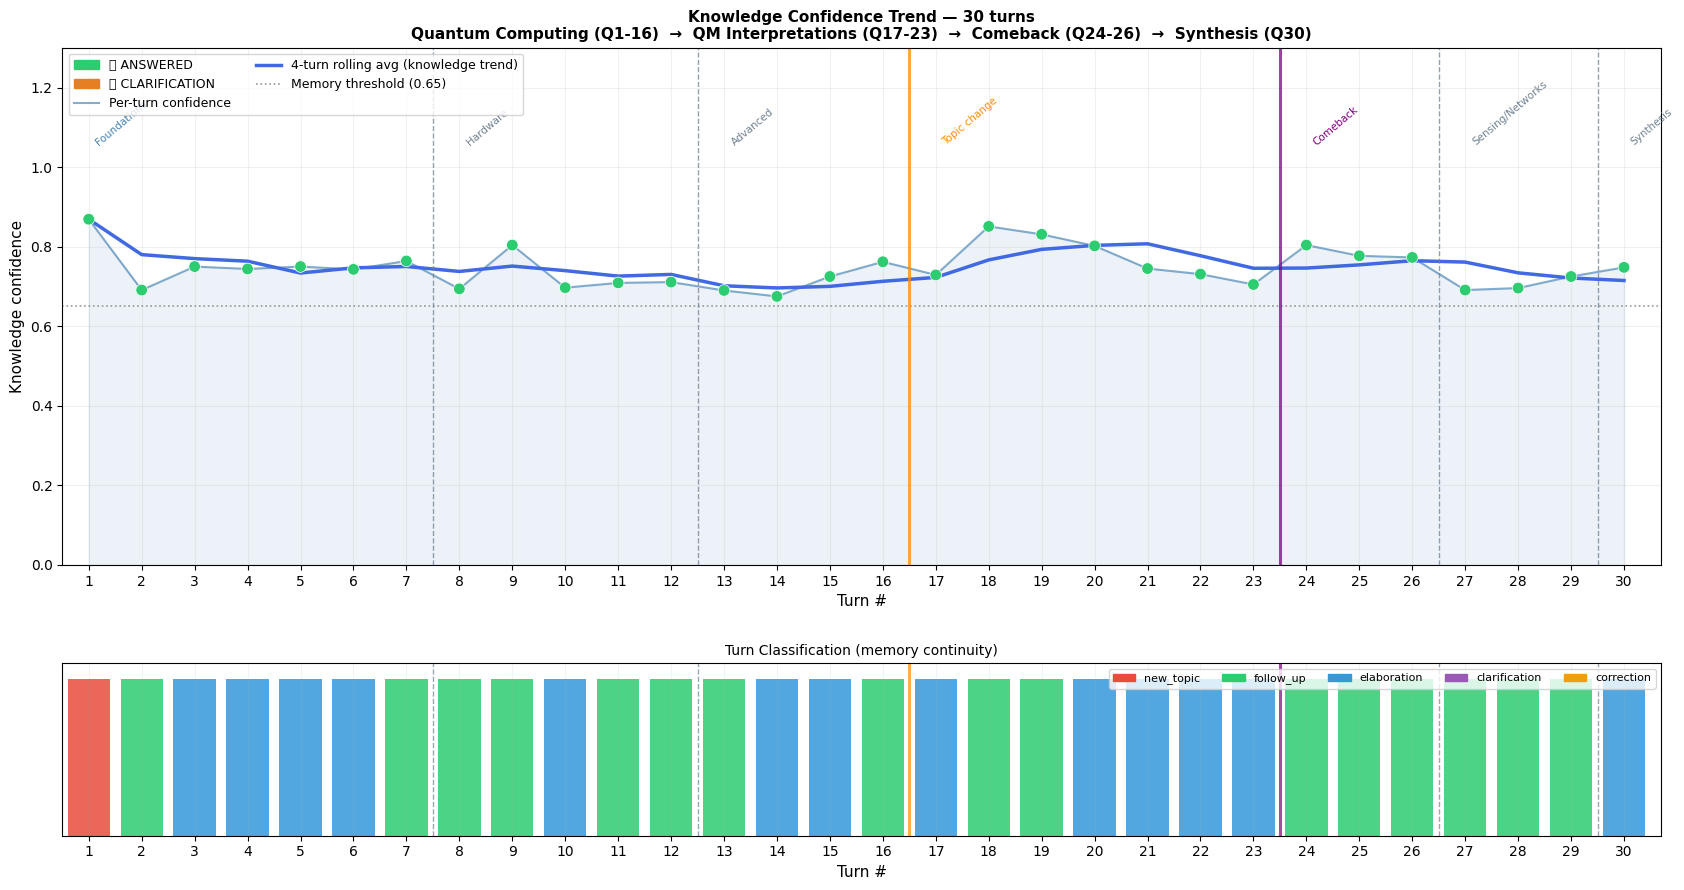

Chart saved → `/content/Brain/quantum_confidence_trend.png`

In [19]:
import time, uuid
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Fresh thread (isolated from every previous test) ─────────────────────────
q30_thread = str(uuid.uuid4())
q30_config = {'configurable': {'thread_id': q30_thread}}

# ── 30 questions — topic arc ──────────────────────────────────────────────────
# Q01-07  Quantum computing foundations
# Q08-12  Hardware & engineering
# Q13-16  Advanced topics
# Q17     ⚡ TOPIC CHANGE — interpretations of quantum mechanics
# Q18-23  QM foundations & philosophy
# Q24     🔄 COMEBACK — connect both threads
# Q25-26  Quantum cryptography
# Q27-29  Quantum sensing & networks
# Q30     Synthesis
Q30_TURNS = [
    # ── Foundations (Q1-7) ──────────────────────────────────────────────────
    "What is a qubit and how does superposition make it fundamentally different from a classical bit?",
    "Explain quantum entanglement — what it is physically, how it is created in the lab, and how it enables correlations that Einstein called 'spooky action at a distance'.",
    "What is quantum decoherence, why does it destroy quantum states, and what timescales are relevant in real superconducting hardware?",
    "Walk me through how quantum gates work — explain the Hadamard, CNOT, and Toffoli gates and their effect on qubit states.",
    "How does Shor's algorithm factor large integers exponentially faster than classical computers? Explain the quantum Fourier transform's role.",
    "Explain Grover's algorithm — what quadratic speedup does it achieve and for what class of problems is it applicable?",
    "What is quantum error correction? State the quantum error-correction conditions and explain why classical error-correction ideas cannot be directly applied.",
    # ── Hardware & engineering (Q8-12) ──────────────────────────────────────
    "Explain the surface code in detail: logical qubits, stabilizer operators, syndrome measurement, and how errors are detected and corrected.",
    "What is the fault-tolerance threshold theorem? What physical gate error rate do current superconducting processors achieve versus the theoretical threshold?",
    "Compare superconducting qubits (IBM, Google), trapped ions (IonQ, Quantinuum), and photonic approaches — tradeoffs in coherence time, gate fidelity, and scalability.",
    "What is the NISQ era? What algorithms can run on today's noisy 100-1000 qubit devices without full error correction?",
    "Critically assess the quantum supremacy claim by Google's Sycamore (2019) and the subsequent counter-arguments from IBM and classical simulation results.",
    # ── Advanced topics (Q13-16) ─────────────────────────────────────────────
    "What are topological qubits? Explain non-Abelian anyons, braiding operations, and why topological protection is theoretically superior for fault tolerance.",
    "How does the variational quantum eigensolver (VQE) work, what Hamiltonian problems does it target, and what are its practical limitations in the NISQ era?",
    "What is quantum volume as a hardware benchmark, and how does it capture holistic device performance better than raw qubit count?",
    "What is the current (2025) state of quantum computing — milestones reached, leading hardware roadmaps, and a realistic timeline to fault-tolerant quantum computing?",
    # ── ⚡ TOPIC CHANGE: Foundations of quantum mechanics (Q17-23) ───────────
    "Setting quantum computers aside — what exactly is the measurement problem in quantum mechanics, and why has it resisted resolution since 1927?",
    "Compare the Copenhagen interpretation, Everett's Many-Worlds, and de Broglie–Bohm pilot-wave theory. What philosophical and empirical grounds distinguish them?",
    "How does decoherence attempt to explain the apparent collapse of the wave function and the emergence of the classical world? Why do critics say it does not fully solve the measurement problem?",
    "What is Carlo Rovelli's relational interpretation of quantum mechanics, and how does QBism (quantum Bayesianism) differ in its treatment of the quantum state?",
    "What exactly does Bell's theorem prove? How do the loophole-free Bell tests (Aspect, Zeilinger, Hensen) constrain local hidden-variable theories?",
    "Is the wave function a real physical object (ψ-ontic) or merely an agent's knowledge state (ψ-epistemic)? What does the Pusey-Barrett-Rudolph theorem imply?",
    "Could quantum mechanics be an emergent effective theory from a deeper deterministic substrate — analogous to thermodynamics emerging from statistical mechanics?",
    # ── 🔄 COMEBACK: Connect both threads (Q24-26) ───────────────────────────
    "Returning to quantum computing through what we just discussed — how does the measurement problem and decoherence theory bear on quantum error correction? Does the interpretation you adopt affect how you design a quantum computer?",
    "What is the quantum computing threat to cryptography? When could a fault-tolerant quantum computer break RSA-2048, and what physical resources — logical qubits, T-gates — would that require?",
    "Which post-quantum cryptography algorithms has NIST standardised (ML-KEM, ML-DSA, SLH-DSA)? How does lattice hardness (LWE/NTRU) resist quantum attacks including Grover's algorithm?",
    # ── Sensing & networks (Q27-29) ─────────────────────────────────────────
    "What is quantum sensing? How do atomic clocks, atom-interferometer gravimeters, and nitrogen-vacancy magnetometers exploit quantum coherence for sensitivity beyond the standard quantum limit?",
    "How does quantum key distribution work? Explain the BB84 protocol, the role of the no-cloning theorem, and why QKD provides information-theoretic rather than computational security.",
    "What is a quantum repeater and why is it needed for a global quantum internet? What physical implementations exist and what are the main engineering challenges?",
    # ── Synthesis (Q30) ─────────────────────────────────────────────────────
    "Synthesise the full arc of our conversation: from qubits and decoherence to error correction, interpretations of quantum mechanics, connecting foundations to engineering, quantum cryptography, and quantum sensing. What are the three deepest open questions at the intersection of quantum foundations and quantum technology?",
]
assert len(Q30_TURNS) == 30, f"Expected 30 questions, got {len(Q30_TURNS)}"

# Section markers used for the confidence trend chart
SECTIONS_Q30 = {
    1:  "Foundations",
    8:  "Hardware",
    13: "Advanced",
    17: "Topic change",
    24: "Comeback",
    27: "Sensing/Networks",
    30: "Synthesis",
}

# Section style config for chart (key = first question in section)
_SECT_STYLE = {
    1:  dict(color="steelblue",  lw=1.0, ls="--"),
    8:  dict(color="slategray",  lw=1.0, ls="--"),
    13: dict(color="slategray",  lw=1.0, ls="--"),
    17: dict(color="darkorange", lw=2.2, ls="-"),
    24: dict(color="purple",     lw=2.2, ls="-"),
    27: dict(color="slategray",  lw=1.0, ls="--"),
    30: dict(color="slategray",  lw=1.0, ls="--"),
}

# ── Run 30-turn conversation ──────────────────────────────────────────────────
q30_results = []
t0_total = time.time()

for idx, goal in enumerate(Q30_TURNS, 1):
    t0 = time.time()
    state = {**EMPTY_STATE, 'goal': goal}

    r = {
        'response': 'Error: max retries exceeded',
        'needs_clarification': False,
        'oriented_context': {},
        'reasoning_trace': [],
    }
    for attempt in range(4):
        try:
            r = graph.invoke(state, config=q30_config)
            break
        except Exception as exc:
            if '429' in str(exc) or 'RESOURCE_EXHAUSTED' in str(exc):
                wait = 20 * (attempt + 1)
                display(Markdown(f'> ⏳ Rate limit on Q{idx} — retrying in {wait}s…'))
                time.sleep(wait)
            elif attempt < 3:
                time.sleep(5)
            else:
                display(Markdown(f'> ❌ Q{idx} failed after 4 attempts: `{str(exc)[:120]}`'))

    elapsed   = time.time() - t0
    ctx_r     = r.get('oriented_context', {})
    turn_type = ctx_r.get('turn_type', '?')
    coverage  = ctx_r.get('coverage', '?')
    conf      = float(ctx_r.get('knowledge_confidence', 0.0))
    trace_len = len(r.get('reasoning_trace', []))

    if r.get('needs_clarification'):
        outcome   = 'CLARIFICATION'
        reason    = r.get('clarification_reason', '')
        why_block = f'\n> **Why:** {reason}\n' if reason else ''
        qs_md     = '\n'.join(f'- {q}' for q in r.get('clarification_questions', []))
        body      = f'{why_block}\n{qs_md}'
    else:
        outcome = 'ANSWERED'
        body    = r.get('response', '*(no response)*')

    # Determine section label for this turn
    section = next(
        SECTIONS_Q30[s]
        for s in sorted(SECTIONS_Q30.keys(), reverse=True)
        if idx >= s
    )

    badge = {'ANSWERED': '🟢', 'CLARIFICATION': '🟡'}.get(outcome, '⚪')
    display(Markdown(f"""---
### Q{idx}/30 &nbsp; {badge} {outcome} &nbsp; · &nbsp; *{section}*
**Q:** *{goal}*
{body}

> `turn_type={turn_type}` &nbsp;|&nbsp; `coverage={coverage}` &nbsp;|&nbsp; `conf={conf:.2f}` &nbsp;|&nbsp; `steps={trace_len}` &nbsp;|&nbsp; `{elapsed:.1f}s`"""))

    q30_results.append(dict(
        n=idx, outcome=outcome, turn_type=turn_type,
        coverage=coverage, conf=conf, secs=elapsed,
    ))

elapsed_total = time.time() - t0_total

# ── Summary table ─────────────────────────────────────────────────────────────
rows = '\n'.join(
    f"| {d['n']:>2} | {'🟢' if d['outcome'] == 'ANSWERED' else '🟡'} {d['outcome']:<14} "
    f"| {d['turn_type']:<12} | {d['coverage']:<9} | {d['conf']:>5.2f} | {d['secs']:>5.1f}s |"
    for d in q30_results
)
display(Markdown(f"""---
## 30-turn summary &nbsp; ⏱ {elapsed_total / 60:.1f} min total

| # | Outcome | Turn type | Coverage | Conf | Time |
|--:|---------|-----------|----------|-----:|------|
{rows}
"""))

# ── Confidence trend chart ─────────────────────────────────────────────────────
turns_x = [d['n']    for d in q30_results]
confs_y = [d['conf'] for d in q30_results]

# 4-turn rolling average (point i = mean of last min(4, i) turns)
window  = 4
rolling = [
    sum(confs_y[max(0, i - window + 1):i + 1]) / min(window, i + 1)
    for i in range(len(confs_y))
]

outcome_colors = [
    '#2ecc71' if d['outcome'] == 'ANSWERED' else '#e67e22'
    for d in q30_results
]
type_palette = {
    'new_topic':    '#e74c3c',
    'follow_up':    '#2ecc71',
    'elaboration':  '#3498db',
    'clarification':'#9b59b6',
    'correction':   '#f39c12',
    '?':            '#95a5a6',
}

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(17, 9),
    gridspec_kw={'height_ratios': [3, 1]},
)

# ── Top panel: confidence trend ───────────────────────────────────────────────
ax1.fill_between(turns_x, confs_y, alpha=0.10, color='steelblue')
# Capture line handles explicitly to avoid _child6 legend artifacts
(line_per_turn,) = ax1.plot(turns_x, confs_y, color='steelblue', linewidth=1.5,
                             alpha=0.65, label='Per-turn confidence')
(line_rolling,)  = ax1.plot(turns_x, rolling, color='royalblue', linewidth=2.5,
                             label=f'{window}-turn rolling avg (knowledge trend)')
ax1.scatter(turns_x, confs_y, c=outcome_colors, s=70, zorder=6,
            edgecolors='white', linewidths=0.5)

# Threshold line — captured explicitly
(line_thresh,) = ax1.plot([], [], color='gray', linestyle=':', linewidth=1.2, alpha=0.8,
                           label='Memory threshold (0.65)')
ax1.axhline(0.65, color='gray', linestyle=':', linewidth=1.2, alpha=0.8)

# Section dividers + labels
for q_num, label in SECTIONS_Q30.items():
    st = _SECT_STYLE.get(q_num, dict(color='gray', lw=1, ls='--'))
    if q_num > 1:
        ax1.axvline(q_num - 0.5, color=st['color'], linestyle=st['ls'],
                    linewidth=st['lw'], alpha=0.75)
    ax1.text(q_num + 0.1, 1.05, label, fontsize=7.5,
             color=st['color'], rotation=40, va='bottom', ha='left')

ax1.set_xlim(0.5, 30.7)
ax1.set_ylim(0, 1.30)
ax1.set_xticks(range(1, 31))
ax1.set_xlabel('Turn #', fontsize=11)
ax1.set_ylabel('Knowledge confidence', fontsize=11)
ax1.set_title(
    'Knowledge Confidence Trend — 30 turns\n'
    'Quantum Computing (Q1-16)  →  QM Interpretations (Q17-23)  →  Comeback (Q24-26)  →  Synthesis (Q30)',
    fontsize=11, fontweight='bold',
)
answered_patch = mpatches.Patch(color='#2ecc71', label='🟢 ANSWERED')
clarif_patch   = mpatches.Patch(color='#e67e22', label='🟡 CLARIFICATION')
ax1.legend(
    handles=[answered_patch, clarif_patch, line_per_turn, line_rolling, line_thresh],
    loc='upper left', fontsize=9, ncol=2,
)
ax1.grid(True, alpha=0.18)

# ── Bottom panel: turn-type bars ──────────────────────────────────────────────
for d in q30_results:
    ax2.bar(d['n'], 1, color=type_palette.get(d['turn_type'], '#95a5a6'),
            alpha=0.85, width=0.8)

for q_num in SECTIONS_Q30:
    if q_num > 1:
        st = _SECT_STYLE.get(q_num, dict(color='gray', lw=1, ls='--'))
        ax2.axvline(q_num - 0.5, color=st['color'], linestyle=st['ls'],
                    linewidth=st['lw'], alpha=0.70)

ax2.set_xlim(0.5, 30.7)
ax2.set_ylim(0, 1.1)
ax2.set_xticks(range(1, 31))
ax2.set_xlabel('Turn #', fontsize=11)
ax2.set_yticks([])
ax2.set_title('Turn Classification (memory continuity)', fontsize=10)
legend_patches = [
    mpatches.Patch(color=c, label=t)
    for t, c in type_palette.items() if t != '?'
]
ax2.legend(handles=legend_patches, loc='upper right', fontsize=8, ncol=5)
ax2.grid(True, alpha=0.15, axis='x')

plt.tight_layout(h_pad=2.5)

chart_path = '/content/Brain/quantum_confidence_trend.png'
plt.savefig(chart_path, dpi=130, bbox_inches='tight')
plt.show()
display(Markdown(f'Chart saved → `{chart_path}`'))
